# Model Governance Notebook

This notebook compares feature-set candidates with apples-to-apples replay outputs.

Primary decision metric:
- `expected_k_mae_on_matched`

Guardrails:
- `k_rate_mae_on_matched`
- calibration (`brier`, `logloss`, `ece`)
- money (`roi`, `clv_mean_pp`)
- risk (`sortino`, `max_drawdown_abs`, `calmar`, `profit_factor`, `cvar_95`, `expectancy_per_bet`, `turnover_stability`)

In [1]:
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "production").exists() and (candidate / "src" / "Python").exists():
        ROOT = candidate
        break

ODDS_DIR = ROOT / "artifacts" / "odds_log"
REPLAY_PATH = ODDS_DIR / "feature_set_governance_compare.csv"

if not REPLAY_PATH.exists():
    raise FileNotFoundError(
        f"Missing {REPLAY_PATH}. Run production/ops/compare_feature_set_governance.py first."
    )

df = pl.read_csv(REPLAY_PATH)
df

feature_set,source_feature_set,monotone_constraints,calibration_mode,matched_rows,n_policy_bets,stake,pnl,roi,roi_ci_lo,roi_ci_hi,clv_mean_pp,clv_ci_lo,clv_ci_hi,go_no_go_replay_ci_gate,expected_k_mae_on_matched,k_rate_mae_on_matched,expected_k_mae_tbf_minus_3pct,expected_k_mae_tbf_plus_3pct,tbf_sensitivity_mae_delta,expected_k_mae_ci_lo,expected_k_mae_ci_hi,brier,logloss,ece,mce,brier_skill_vs_market,logloss_skill_vs_market,kappa,sortino,max_drawdown_abs,max_drawdown_pct,max_recovery_bets,calmar,profit_factor,cvar_95,expectancy_per_bet,turnover_stability,calibration_meta
str,str,bool,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""production_sparse72""","""production_sparse72""",false,"""raw""",292,113,10168.047301,3086.384193,0.303538,0.044045,0.410832,0.008945,0.0002,0.018944,true,1.645062,0.071396,1.645677,1.653198,0.008136,1.627073,1.663423,0.256298,0.708908,0.133852,0.607395,-0.02616,-0.02344,997377.747455,0.305459,785.391839,3.360262,26.0,3.929738,1.888525,-152.951668,27.313134,0.430388,null
"""production_sparse72""","""production_sparse72""",false,"""platt""",292,14,2155.042406,1453.966107,0.674681,null,null,0.012484,null,null,false,1.645062,0.071396,1.645677,1.653198,0.008136,1.627073,1.663423,0.239567,0.672079,0.062734,0.435056,0.040826,0.02973,997377.747455,0.563926,368.319578,0.608242,5.0,3.947567,4.947567,-185.374556,103.854722,0.732739,"""{'platt_a': 0.8202762427750283…"
"""production_sparse72""","""production_sparse72""",false,"""isotonic""",292,29,3652.241626,1622.529819,0.444256,0.007434,0.711896,0.00823,null,null,false,1.645062,0.071396,1.645677,1.653198,0.008136,1.627073,1.663423,0.230219,0.650031,1.0274e-8,0.000001,0.078256,0.06156,997377.747455,0.454458,368.319578,0.608242,7.0,4.405223,2.613377,-184.159789,55.949304,0.566558,null
"""production_sparse72_monotone""","""production_sparse72""",true,"""isotonic""",292,31,3572.614927,2010.585198,0.562777,0.339028,0.779632,-0.000611,-0.017612,0.015281,false,1.64562,0.071371,1.645793,1.653964,0.008344,1.62748,1.664278,0.223119,0.631714,1.7123e-8,0.000001,0.106682,0.088003,998125.544508,0.454695,368.319578,0.546327,6.0,5.458806,4.774973,-184.159789,64.857587,0.493025,null
"""production_sparse72_monotone""","""production_sparse72""",true,"""platt""",292,21,2983.700257,1379.448484,0.462328,null,null,0.022422,null,null,false,1.64562,0.071371,1.645793,1.653964,0.008344,1.62748,1.664278,0.237664,0.667486,0.024079,0.081408,0.048448,0.03636,998125.544508,0.419898,643.110064,0.987299,9.0,2.144965,2.785385,-184.159789,65.688023,0.505128,"""{'platt_a': 0.8893313491871183…"
"""production_sparse72_monotone""","""production_sparse72""",true,"""raw""",292,109,9921.357655,1601.554845,0.161425,-0.119601,0.246195,0.008531,-0.001141,0.018408,false,1.64562,0.071371,1.645793,1.653964,0.008344,1.62748,1.664278,0.25308,0.700674,0.129312,0.237463,-0.013277,-0.011553,998125.544508,0.166102,942.476824,3.589467,29.0,1.699304,1.398586,-152.951668,14.693164,0.52373,null
"""production_final58_consensus""","""production_final58_consensus""",false,"""isotonic""",292,26,3186.702975,1743.381491,0.54708,0.291375,0.957977,0.022146,null,null,false,1.650837,0.071651,1.6508,1.659842,0.009004,1.633471,1.669376,0.237575,0.667848,2.3193e-17,1.1102e-16,0.048801,0.035838,997414.165323,0.432742,368.319578,0.565442,7.0,4.733339,3.285264,-184.159789,67.053134,0.607768,null
"""production_final58_consensus""","""production_final58_consensus""",false,"""raw""",292,111,10281.638017,2371.158119,0.230621,-0.009862,0.364178,0.005929,-0.003101,0.014504,false,1.650837,0.071651,1.6508,1.659842,0.009004,1.633471,1.669376,0.263164,0.724352,0.127208,0.738237,-0.053651,-0.045736,997414.165323,0.228786,1015.684009,1.155879,34.0,2.334543,1.609906,-152.951668,21.361785,0.362839,null
"""production_final58_consensus""","""production_final58_consensus""",false,"""platt""",292,1,129.523506,-129.523506,-1.0,null,null,0.058686,null,nu

In [2]:
core_cols = [
    "feature_set",
    "calibration_mode",
    "expected_k_mae_on_matched",
    "k_rate_mae_on_matched",
    "expected_k_mae_tbf_minus_3pct",
    "expected_k_mae_tbf_plus_3pct",
    "tbf_sensitivity_mae_delta",
    "brier",
    "logloss",
    "ece",
    "mce",
    "brier_skill_vs_market",
    "logloss_skill_vs_market",
    "roi",
    "clv_mean_pp",
    "sortino",
    "max_drawdown_abs",
    "max_drawdown_pct",
    "max_recovery_bets",
    "calmar",
    "profit_factor",
    "cvar_95",
    "expectancy_per_bet",
    "turnover_stability",
    "go_no_go_replay_ci_gate",
    "n_policy_bets",
]

ranked = (
    df.select([c for c in core_cols if c in df.columns])
    .sort(
        ["go_no_go_replay_ci_gate", "expected_k_mae_on_matched", "tbf_sensitivity_mae_delta", "roi"],
        descending=[True, False, False, True],
    )
)
ranked

feature_set,calibration_mode,expected_k_mae_on_matched,k_rate_mae_on_matched,expected_k_mae_tbf_minus_3pct,expected_k_mae_tbf_plus_3pct,tbf_sensitivity_mae_delta,brier,logloss,ece,mce,brier_skill_vs_market,logloss_skill_vs_market,roi,clv_mean_pp,sortino,max_drawdown_abs,max_drawdown_pct,max_recovery_bets,calmar,profit_factor,cvar_95,expectancy_per_bet,turnover_stability,go_no_go_replay_ci_gate,n_policy_bets
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,i64
"""production_sparse72""","""raw""",1.645062,0.071396,1.645677,1.653198,0.008136,0.256298,0.708908,0.133852,0.607395,-0.02616,-0.02344,0.303538,0.008945,0.305459,785.391839,3.360262,26.0,3.929738,1.888525,-152.951668,27.313134,0.430388,true,113
"""production_sparse72""","""platt""",1.645062,0.071396,1.645677,1.653198,0.008136,0.239567,0.672079,0.062734,0.435056,0.040826,0.02973,0.674681,0.012484,0.563926,368.319578,0.608242,5.0,3.947567,4.947567,-185.374556,103.854722,0.732739,false,14
"""production_sparse72""","""isotonic""",1.645062,0.071396,1.645677,1.653198,0.008136,0.230219,0.650031,1.0274e-8,0.000001,0.078256,0.06156,0.444256,0.00823,0.454458,368.319578,0.608242,7.0,4.405223,2.613377,-184.159789,55.949304,0.566558,false,29
"""production_sparse72_monotone""","""isotonic""",1.64562,0.071371,1.645793,1.653964,0.008344,0.223119,0.631714,1.7123e-8,0.000001,0.106682,0.088003,0.562777,-0.000611,0.454695,368.319578,0.546327,6.0,5.458806,4.774973,-184.159789,64.857587,0.493025,false,31
"""production_sparse72_monotone""","""platt""",1.64562,0.071371,1.645793,1.653964,0.008344,0.237664,0.667486,0.024079,0.081408,0.048448,0.03636,0.462328,0.022422,0.419898,643.110064,0.987299,9.0,2.144965,2.785385,-184.159789,65.688023,0.505128,false,21
"""production_sparse72_monotone""","""raw""",1.64562,0.071371,1.645793,1.653964,0.008344,0.25308,0.700674,0.129312,0.237463,-0.013277,-0.011553,0.161425,0.008531,0.166102,942.476824,3.589467,29.0,1.699304,1.398586,-152.951668,14.693164,0.52373,false,109
"""production_final58_consensus""","""isotonic""",1.650837,0.071651,1.6508,1.659842,0.009004,0.237575,0.667848,2.3193e-17,1.1102e-16,0.048801,0.035838,0.54708,0.022146,0.432742,368.319578,0.565442,7.0,4.733339,3.285264,-184.159789,67.053134,0.607768,false,26
"""production_final58_consensus""","""raw""",1.650837,0.071651,1.6508,1.659842,0.009004,0.263164,0.724352,0.127208,0.738237,-0.053651,-0.045736,0.230621,0.005929,0.228786,1015.684009,1.155879,34.0,2.334543,1.609906,-152.951668,21.361785,0.362839,false,111
"""production_final58_consensus""","""platt""",1.650837,0.071651,1.6508,1.659842,0.009004,0.246069,0.685374,0.00952,0.064003,0.014794,0.010535,-1.0,0.058686,-1.0,0.0,0.0,null,null,0.0,-129.523506,-129.523506,null,false,1


In [3]:
# Calibration-mode parity view per feature set
pivot = (
    ranked
    .select([
        "feature_set",
        "calibration_mode",
        "expected_k_mae_on_matched",
        "k_rate_mae_on_matched",
        "brier",
        "logloss",
        "ece",
        "roi",
        "sortino",
    ])
    .pivot(
        values=[
            "expected_k_mae_on_matched",
            "k_rate_mae_on_matched",
            "brier",
            "logloss",
            "ece",
            "roi",
            "sortino",
        ],
        index="feature_set",
        columns="calibration_mode",
    )
)
pivot

C:\Users\ckaplinger\AppData\Local\Temp\ipykernel_29264\634860926.py:15: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(


feature_set,expected_k_mae_on_matched_raw,expected_k_mae_on_matched_platt,expected_k_mae_on_matched_isotonic,k_rate_mae_on_matched_raw,k_rate_mae_on_matched_platt,k_rate_mae_on_matched_isotonic,brier_raw,brier_platt,brier_isotonic,logloss_raw,logloss_platt,logloss_isotonic,ece_raw,ece_platt,ece_isotonic,roi_raw,roi_platt,roi_isotonic,sortino_raw,sortino_platt,sortino_isotonic
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""production_sparse72""",1.645062,1.645062,1.645062,0.071396,0.071396,0.071396,0.256298,0.239567,0.230219,0.708908,0.672079,0.650031,0.133852,0.062734,1.0274e-8,0.303538,0.674681,0.444256,0.305459,0.563926,0.454458
"""production_sparse72_monotone""",1.64562,1.64562,1.64562,0.071371,0.071371,0.071371,0.25308,0.237664,0.223119,0.700674,0.667486,0.631714,0.129312,0.024079,1.7123e-8,0.161425,0.462328,0.562777,0.166102,0.419898,0.454695
"""production_final58_consensus""",1.650837,1.650837,1.650837,0.071651,0.071651,0.071651,0.263164,0.246069,0.237575,0.724352,0.685374,0.667848,0.127208,0.00952,2.3193e-17,0.230621,-1.0,0.54708,0.228786,-1.0,0.432742


Top candidate row:
shape: (1, 26)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ feature_s ┆ calibrati ┆ expected_ ┆ k_rate_ma ┆ … ┆ expectanc ┆ turnover_ ┆ go_no_go_ ┆ n_policy │
│ et        ┆ on_mode   ┆ k_mae_on_ ┆ e_on_matc ┆   ┆ y_per_bet ┆ stability ┆ replay_ci ┆ _bets    │
│ ---       ┆ ---       ┆ matched   ┆ hed       ┆   ┆ ---       ┆ ---       ┆ _gate     ┆ ---      │
│ str       ┆ str       ┆ ---       ┆ ---       ┆   ┆ f64       ┆ f64       ┆ ---       ┆ i64      │
│           ┆           ┆ f64       ┆ f64       ┆   ┆           ┆           ┆ bool      ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ productio ┆ raw       ┆ 1.645062  ┆ 0.071396  ┆ … ┆ 27.313134 ┆ 0.430388  ┆ true      ┆ 113      │
│ n_sparse7 ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ 2         ┆           ┆           ┆           ┆   ┆    

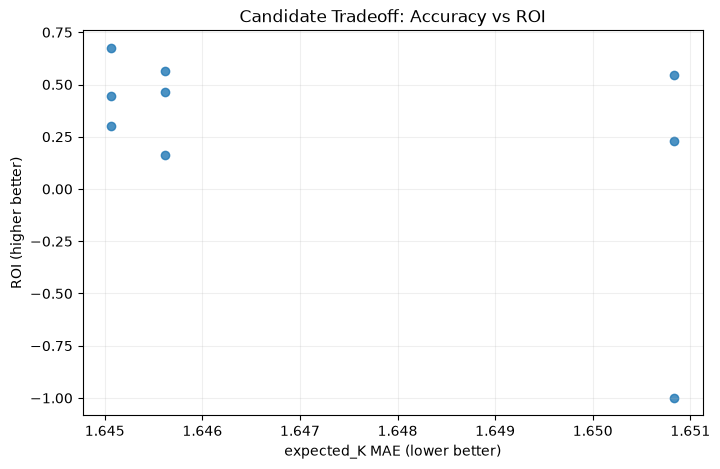

In [4]:
# Rolling stability proxy: daily policy turnover dispersion
if "n_policy_bets" in df.columns:
    best = ranked.head(1)
    print("Top candidate row:")
    print(best)

# Optional quick scan chart: expected_K MAE vs ROI
pdf = ranked.to_pandas()
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    pdf["expected_k_mae_on_matched"],
    pdf["roi"],
    alpha=0.8,
)
ax.set_xlabel("expected_K MAE (lower better)")
ax.set_ylabel("ROI (higher better)")
ax.set_title("Candidate Tradeoff: Accuracy vs ROI")
ax.grid(alpha=0.2)
plt.show()

In [5]:
RANK_PATH = ODDS_DIR / "feature_set_governance_ranked.csv"
DAILY_PATH = ODDS_DIR / "feature_set_governance_daily.csv"
SEG_PATH = ODDS_DIR / "feature_set_governance_segments.csv"

ranked_governance = pl.read_csv(RANK_PATH) if RANK_PATH.exists() else pl.DataFrame()
daily_governance = pl.read_csv(DAILY_PATH) if DAILY_PATH.exists() else pl.DataFrame()
segment_governance = pl.read_csv(SEG_PATH) if SEG_PATH.exists() else pl.DataFrame()

print("ranked rows:", ranked_governance.height)
print("daily rows:", daily_governance.height)
print("segment rows:", segment_governance.height)
ranked_governance.head(15)

ranked rows: 9
daily rows: 91
segment rows: 78


feature_set,source_feature_set,monotone_constraints,calibration_mode,matched_rows,n_policy_bets,stake,pnl,roi,roi_ci_lo,roi_ci_hi,clv_mean_pp,clv_ci_lo,clv_ci_hi,go_no_go_replay_ci_gate,expected_k_mae_on_matched,k_rate_mae_on_matched,expected_k_mae_tbf_minus_3pct,expected_k_mae_tbf_plus_3pct,tbf_sensitivity_mae_delta,expected_k_mae_ci_lo,expected_k_mae_ci_hi,brier,logloss,ece,mce,brier_skill_vs_market,logloss_skill_vs_market,kappa,sortino,max_drawdown_abs,max_drawdown_pct,max_recovery_bets,calmar,profit_factor,cvar_95,expectancy_per_bet,turnover_stability,calibration_meta,gate_min_bets,gate_expected_k_mae,gate_k_rate_mae,gate_calibration,gate_risk,gate_tbf_stability,gate_pass_count,composite_score
str,str,bool,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,bool,bool,bool,bool,bool,bool,i64,f64
"""production_sparse72_monotone""","""production_sparse72""",true,"""isotonic""",292,31,3572.614927,2010.585198,0.562777,0.339028,0.779632,-0.000611,-0.017612,0.015281,false,1.64562,0.071371,1.645793,1.653964,0.008344,1.62748,1.664278,0.223119,0.631714,1.7123e-8,0.000001,0.106682,0.088003,998125.544508,0.454695,368.319578,0.546327,6.0,5.458806,4.774973,-184.159789,64.857587,0.493025,null,true,true,true,true,true,true,6,-145.596366
"""production_final58_consensus""","""production_final58_consensus""",false,"""isotonic""",292,26,3186.702975,1743.381491,0.54708,0.291375,0.957977,0.022146,null,null,false,1.650837,0.071651,1.6508,1.659842,0.009004,1.633471,1.669376,0.237575,0.667848,2.3193e-17,1.1102e-16,0.048801,0.035838,997414.165323,0.432742,368.319578,0.565442,7.0,4.733339,3.285264,-184.159789,67.053134,0.607768,null,true,true,true,true,true,true,6,-149.649403
"""production_sparse72""","""production_sparse72""",false,"""isotonic""",292,29,3652.241626,1622.529819,0.444256,0.007434,0.711896,0.00823,null,null,false,1.645062,0.071396,1.645677,1.653198,0.008136,1.627073,1.663423,0.230219,0.650031,1.0274e-8,0.000001,0.078256,0.06156,997377.747455,0.454458,368.319578,0.608242,7.0,4.405223,2.613377,-184.159789,55.949304,0.566558,null,true,true,true,true,true,true,6,-152.3066
"""production_sparse72""","""production_sparse72""",false,"""raw""",292,113,10168.047301,3086.384193,0.303538,0.044045,0.410832,0.008945,0.0002,0.018944,true,1.645062,0.071396,1.645677,1.653198,0.008136,1.627073,1.663423,0.256298,0.708908,0.133852,0.607395,-0.02616,-0.02344,997377.747455,0.305459,785.391839,3.360262,26.0,3.929738,1.888525,-152.951668,27.313134,0.430388,null,true,true,true,false,true,true,5,-157.427459
"""production_sparse72""","""production_sparse72""",false,"""platt""",292,14,2155.042406,1453.966107,0.674681,null,null,0.012484,null,null,false,1.645062,0.071396,1.645677,1.653198,0.008136,1.627073,1.663423,0.239567,0.672079,0.062734,0.435056,0.040826,0.02973,997377.747455,0.563926,368.319578,0.608242,5.0,3.947567,4.947567,-185.374556,103.854722,0.732739,"""{'platt_a': 0.8202762427750283…",false,true,true,true,true,true,5,-142.685335
"""production_sparse72_monotone""","""production_sparse72""",true,"""platt""",292,21,2983.700257,1379.448484,0.462328,null,null,0.022422,null,null,false,1.64562,0.071371,1.645793,1.653964,0.008344,1.62748,1.664278,0.237664,0.667486,0.024079,0.081408,0.048448,0.03636,998125.544508,0.419898,643.110064,0.987299,9.0,2.144965,2.785385,-184.159789,65.688023,0.505128,"""{'platt_a': 0.8893313491871183…",false,true,true,true,true,true,5,-151.869154
"""production_final58_consensus""","""production_final58_consensus""",false,"""raw""",292,111,10281.638017,2371.158119,0.230621,-0.009862,0.364178,0.005929,-0.003101,0.014504,false,1.650837,0.071651,1.6508,1.659842,0.009004,1.633471,1.669376,0.263164,0.724352,0.127208,0.738237,-0.053651,-0.045736,997414.165323,0.228786,1015.684009,1.155879,34.0,2.334543,1.609906,-152.951668,21.361785,0.362839,null,true,true,true,false,false,true,4,-160.401018
"""production_sparse72_monotone""","""production_sparse72"

In [6]:
# Regime stability snapshot (side / market / odds / line bands)
segment_summary = (
    segment_governance
    .group_by(["feature_set", "calibration_mode", "segment_type"])
    .agg([
        pl.col("roi").mean().alias("roi_mean_across_segments"),
        pl.col("roi").std().alias("roi_std_across_segments"),
        pl.col("n_bets").sum().alias("n_bets_total"),
    ])
    .with_columns(
        pl.when(pl.col("roi_mean_across_segments").abs() > 1e-9)
        .then(pl.col("roi_std_across_segments") / pl.col("roi_mean_across_segments").abs())
        .otherwise(None)
        .alias("roi_dispersion_ratio")
    )
    .sort(["feature_set", "calibration_mode", "segment_type"])
)
segment_summary

feature_set,calibration_mode,segment_type,roi_mean_across_segments,roi_std_across_segments,n_bets_total,roi_dispersion_ratio
str,str,str,f64,f64,i64,f64
"""production_final58_consensus""","""isotonic""","""line_band""",0.576953,0.441868,26,0.765864
"""production_final58_consensus""","""isotonic""","""market""",0.54708,null,26,null
"""production_final58_consensus""","""isotonic""","""odds_band""",0.502169,0.4546,26,0.905272
"""production_final58_consensus""","""isotonic""","""side""",0.36213,0.329853,26,0.91087
"""production_final58_consensus""","""platt""","""line_band""",-1.0,null,1,null
…,…,…,…,…,…,…
"""production_sparse72_monotone""","""platt""","""side""",0.72697,0.386123,21,0.531141
"""production_sparse72_monotone""","""raw""","""line_band""",0.035215,0.394852,109,11.212596
"""production_sparse72_monotone""","""raw""","""market""",0.161425,null,109,null


In [7]:
# Freeze-vs-continue decision frame
must_cols = [
    "feature_set",
    "calibration_mode",
    "gate_pass_count",
    "expected_k_mae_on_matched",
    "k_rate_mae_on_matched",
    "brier",
    "ece",
    "roi",
    "sortino",
    "profit_factor",
    "tbf_sensitivity_mae_delta",
]

view = ranked_governance.select([c for c in must_cols if c in ranked_governance.columns]).head(20)
view

if view.height > 0:
    top = view.row(0, named=True)
    print("\nTop current candidate:")
    print(top)
    if top.get("gate_pass_count", 0) >= 5:
        print("\nPreliminary verdict: close to freeze-quality; run final segment and CI checks before hard freeze.")
    else:
        print("\nPreliminary verdict: continue search; candidate does not clear enough governance gates yet.")


Top current candidate:
{'feature_set': 'production_sparse72_monotone', 'calibration_mode': 'isotonic', 'gate_pass_count': 6, 'expected_k_mae_on_matched': 1.645620324943329, 'k_rate_mae_on_matched': 0.07137051823120186, 'brier': 0.22311895043061142, 'ece': 1.7123287802314858e-08, 'roi': 0.5627769124956123, 'sortino': 0.4546953499434524, 'profit_factor': 4.774973299994099, 'tbf_sensitivity_mae_delta': 0.008343560231764968}

Preliminary verdict: close to freeze-quality; run final segment and CI checks before hard freeze.


In [8]:
# Calibration quality extension: MCE + skill-vs-market view
calib_cols = [
    "feature_set",
    "calibration_mode",
    "n_policy_bets",
    "brier",
    "logloss",
    "ece",
    "mce",
    "brier_skill_vs_market",
    "logloss_skill_vs_market",
]

calib_view = (
    ranked_governance.select([c for c in calib_cols if c in ranked_governance.columns])
    .sort(["brier_skill_vs_market", "logloss_skill_vs_market", "ece"], descending=[True, True, False])
)
calib_view.head(20)

feature_set,calibration_mode,n_policy_bets,brier,logloss,ece,mce,brier_skill_vs_market,logloss_skill_vs_market
str,str,i64,f64,f64,f64,f64,f64,f64
"""production_sparse72_monotone""","""isotonic""",31,0.223119,0.631714,1.7123e-8,0.000001,0.106682,0.088003
"""production_sparse72""","""isotonic""",29,0.230219,0.650031,1.0274e-8,0.000001,0.078256,0.06156
"""production_final58_consensus""","""isotonic""",26,0.237575,0.667848,2.3193e-17,1.1102e-16,0.048801,0.035838
"""production_sparse72_monotone""","""platt""",21,0.237664,0.667486,0.024079,0.081408,0.048448,0.03636
"""production_sparse72""","""platt""",14,0.239567,0.672079,0.062734,0.435056,0.040826,0.02973
"""production_final58_consensus""","""platt""",1,0.246069,0.685374,0.00952,0.064003,0.014794,0.010535
"""production_sparse72_monotone""","""raw""",109,0.25308,0.700674,0.129312,0.237463,-0.013277,-0.011553
"""production_sparse72""","""raw""",113,0.256298,0.708908,0.133852,0.607395,-0.02616,-0.02344
"""production_final58_consensus""","""raw""",111,0.263164,0.724352,0.127208,0.738237,-0.053651,-0.045736


Top candidate: production_sparse72_monotone [isotonic]
shape: (10, 5)
┌─────────────┬────────┬───────────┬───────────┬─────────────┐
│ edge_decile ┆ n_bets ┆ mean_edge ┆ roi       ┆ mean_clv_pp │
│ ---         ┆ ---    ┆ ---       ┆ ---       ┆ ---         │
│ i64         ┆ i64    ┆ f64       ┆ f64       ┆ f64         │
╞═════════════╪════════╪═══════════╪═══════════╪═════════════╡
│ 1           ┆ 3      ┆ 0.196962  ┆ 0.624928  ┆ -0.047683   │
│ 2           ┆ 3      ┆ 0.234339  ┆ -0.363482 ┆ -0.006494   │
│ 3           ┆ 3      ┆ 0.295925  ┆ 0.888401  ┆ -0.026891   │
│ 4           ┆ 3      ┆ 0.311062  ┆ 0.794854  ┆ 0.001399    │
│ 5           ┆ 3      ┆ 0.341189  ┆ 0.675635  ┆ -0.012196   │
│ 6           ┆ 3      ┆ 0.360667  ┆ -0.590046 ┆ -0.003238   │
│ 7           ┆ 3      ┆ 0.388881  ┆ 0.835483  ┆ -0.010295   │
│ 8           ┆ 3      ┆ 0.401299  ┆ 0.872516  ┆ 0.005566    │
│ 9           ┆ 3      ┆ 0.427512  ┆ 0.96384   ┆ 0.038031    │
│ 10          ┆ 4      ┆ 0.449667  ┆ 0.956641  ┆

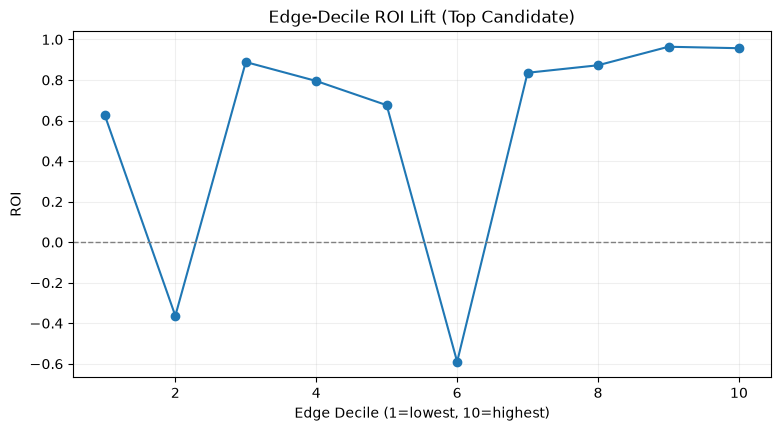

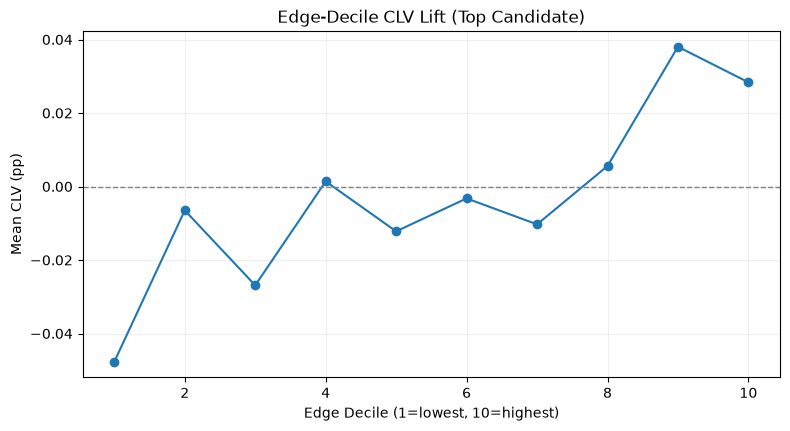

In [9]:
# Edge-decile lift: does higher edge realize better ROI/CLV?
EDGE_DECILE_PATH = ODDS_DIR / "feature_set_governance_edge_deciles.csv"
edge_dec = pl.read_csv(EDGE_DECILE_PATH) if EDGE_DECILE_PATH.exists() else pl.DataFrame()

if edge_dec.is_empty():
    print(f"Missing {EDGE_DECILE_PATH}. Re-run compare_feature_set_governance.py")
else:
    top = ranked_governance.sort(
        ["gate_pass_count", "composite_score"],
        descending=[True, True],
    ).head(1)
    if top.height == 0:
        print("No ranked governance rows available.")
    else:
        top_row = top.row(0, named=True)
        fs = str(top_row.get("feature_set"))
        cm = str(top_row.get("calibration_mode"))
        lift = edge_dec.filter(
            (pl.col("feature_set") == fs) & (pl.col("calibration_mode") == cm)
        ).sort("edge_decile")

        print(f"Top candidate: {fs} [{cm}]")
        display_cols = [
            "edge_decile",
            "n_bets",
            "mean_edge",
            "roi",
            "mean_clv_pp",
        ]
        print(lift.select([c for c in display_cols if c in lift.columns]))

        if lift.height > 0:
            pdf_lift = lift.to_pandas()
            fig, ax = plt.subplots(figsize=(9, 4.5))
            ax.plot(pdf_lift["edge_decile"], pdf_lift["roi"], marker="o", label="ROI")
            ax.axhline(0, color="gray", linestyle="--", linewidth=1)
            ax.set_xlabel("Edge Decile (1=lowest, 10=highest)")
            ax.set_ylabel("ROI")
            ax.set_title("Edge-Decile ROI Lift (Top Candidate)")
            ax.grid(alpha=0.2)
            plt.show()

            fig, ax = plt.subplots(figsize=(9, 4.5))
            ax.plot(pdf_lift["edge_decile"], pdf_lift["mean_clv_pp"], marker="o", label="Mean CLV pp")
            ax.axhline(0, color="gray", linestyle="--", linewidth=1)
            ax.set_xlabel("Edge Decile (1=lowest, 10=highest)")
            ax.set_ylabel("Mean CLV (pp)")
            ax.set_title("Edge-Decile CLV Lift (Top Candidate)")
            ax.grid(alpha=0.2)
            plt.show()

In [10]:
# Drawdown and recovery quality panel
risk_cols = [
    "feature_set",
    "calibration_mode",
    "n_policy_bets",
    "roi",
    "sortino",
    "max_drawdown_abs",
    "max_drawdown_pct",
    "max_recovery_bets",
    "cvar_95",
    "profit_factor",
]

risk_view = ranked_governance.select([c for c in risk_cols if c in ranked_governance.columns])

# Lower drawdown/recovery is better; higher sortino/profit factor is better.
risk_ranked = risk_view.sort(
    ["max_drawdown_pct", "max_recovery_bets", "sortino", "profit_factor"],
    descending=[False, False, True, True],
)
risk_ranked.head(20)

feature_set,calibration_mode,n_policy_bets,roi,sortino,max_drawdown_abs,max_drawdown_pct,max_recovery_bets,cvar_95,profit_factor
str,str,i64,f64,f64,f64,f64,f64,f64,f64
"""production_final58_consensus""","""platt""",1,-1.0,-1.0,0.0,0.0,null,-129.523506,0.0
"""production_sparse72_monotone""","""isotonic""",31,0.562777,0.454695,368.319578,0.546327,6.0,-184.159789,4.774973
"""production_final58_consensus""","""isotonic""",26,0.54708,0.432742,368.319578,0.565442,7.0,-184.159789,3.285264
"""production_sparse72""","""platt""",14,0.674681,0.563926,368.319578,0.608242,5.0,-185.374556,4.947567
"""production_sparse72""","""isotonic""",29,0.444256,0.454458,368.319578,0.608242,7.0,-184.159789,2.613377
"""production_sparse72_monotone""","""platt""",21,0.462328,0.419898,643.110064,0.987299,9.0,-184.159789,2.785385
"""production_final58_consensus""","""raw""",111,0.230621,0.228786,1015.684009,1.155879,34.0,-152.951668,1.609906
"""production_sparse72""","""raw""",113,0.303538,0.305459,785.391839,3.360262,26.0,-152.951668,1.888525
"""production_sparse72_monotone""","""raw""",109,0.161425,0.166102,942.476824,3.589467,29.0,-152.951668,1.398586
